<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> I love Python

<font color='black'>

- Luis Fernando Márquez Bañuelos

In [1]:
import warnings
import numpy as np
import pandas as pd
import scipy.io as sio
import plotly.express as px
import ipywidgets as widgets
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray):
    fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)

    distances   = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_idx    = np.argmin(distances)
    best_thr    = thresholds[best_idx]
    best_fpr    = fpr[best_idx]
    best_tpr    = tpr[best_idx]
    auc_score   = roc_auc_score(y_test, probabilidades)

    fig, ax = plt.subplots(figsize=(9, 5))

    # Área bajo la curva sombreada
    ax.fill_between(fpr, tpr, alpha=0.08, color='#2E86AB')

    ax.plot(fpr, tpr, color='#2E86AB', lw=2,
            label=f'AUC = {auc_score:.3f}')
    ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5,
            linestyle='--', label='Random classifier')

    # Líneas guía al mejor threshold
    ax.plot([best_fpr, best_fpr], [0, best_tpr],
            color='#F4A261', lw=1, linestyle=':')
    ax.plot([0, best_fpr], [best_tpr, best_tpr],
            color='#F4A261', lw=1, linestyle=':')

    # Estrella
    ax.scatter(best_fpr, best_tpr, marker='*', s=400,
               color='#F4A261', zorder=5,
               label=f'Best threshold = {best_thr:.3f}\n'
                     f'FPR={best_fpr:.3f}  TPR={best_tpr:.3f}')

    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
    ax.set_title('ROC Curve — Credit Default XGBoost',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10, framealpha=0.9, loc='lower right')

    plt.tight_layout()
    plt.show()

## <font color='cornflowerblue'> Data

In [2]:
# Load the new .mat file (numeric matrices, no MATLAB table objects)
mat = sio.loadmat('data/creditCardDefault-2.mat')

# Check contents
print(mat.keys())

# Extract matrices
data_train = mat['train']
data_test = mat['test']

print(f'Train shape: {data_train.shape}')
print(f'Test shape:  {data_test.shape}')

dict_keys(['__header__', '__version__', '__globals__', 'test', 'train'])
Train shape: (2000, 13)
Test shape:  (1000, 13)


In [3]:
# Column order from trainClassifier.m:
col_names = ['id','creditLimit', 'gender', 'edu', 'age', 'nDelay',
             'billAmt1', 'billAmt2', 'billAmt3', 'billAmt4',
             'billAmt5', 'billAmt6', 'default']

data_train = pd.DataFrame(data_train, columns=col_names)
data_test  = pd.DataFrame(data_test,  columns=col_names)

# Adjust target values to 0 and 1
data_train['default'] = data_train['default'].astype(int)
data_test['default']  = data_test['default'].astype(int)
data_train['default'] = data_train['default'] - 1
data_test['default']  = data_test['default']  - 1

In [4]:
data_train

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1.0,4500.0,0.0,2.0,28.0,0.0,3915.0,3150.0,2475.0,2340.0,2385.0,2430.0,0
1,2.0,6000.0,0.0,2.0,24.0,0.0,2820.0,2700.0,2760.0,2400.0,2280.0,2280.0,1
2,3.0,3800.0,0.0,2.0,39.0,0.0,3572.0,3648.0,3762.0,2166.0,2204.0,2242.0,0
3,4.0,5500.0,1.0,1.0,27.0,0.0,5280.0,5445.0,5390.0,2585.0,2640.0,2695.0,1
4,5.0,18000.0,1.0,1.0,51.0,2.0,3780.0,3780.0,3780.0,1800.0,1620.0,720.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996.0,18000.0,1.0,1.0,34.0,0.0,180.0,180.0,180.0,180.0,180.0,180.0,0
1996,1997.0,33300.0,1.0,1.0,34.0,0.0,333.0,333.0,2664.0,333.0,333.0,2331.0,0
1997,1998.0,33000.0,1.0,2.0,35.0,0.0,18150.0,17820.0,17490.0,15510.0,15840.0,15840.0,1
1998,1999.0,18200.0,1.0,1.0,36.0,0.0,182.0,364.0,0.0,182.0,182.0,182.0,0


In [5]:
data_test

,id,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6,default
0,1.0,1500.0,0.0,3.0,31.0,2.0,1350.0,1530.0,1455.0,1515.0,1530.0,1515.0,0
1,2.0,10900.0,0.0,1.0,47.0,0.0,8720.0,9047.0,9374.0,0.0,0.0,2834.0,0
2,3.0,3600.0,1.0,2.0,54.0,3.0,2520.0,2448.0,2808.0,2736.0,2700.0,2880.0,1
3,4.0,4200.0,0.0,1.0,25.0,0.0,4116.0,3990.0,3906.0,1764.0,1722.0,1722.0,0
4,5.0,19200.0,0.0,5.0,53.0,0.0,12864.0,13056.0,12864.0,6144.0,3840.0,11904.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,4200.0,1.0,3.0,53.0,0.0,6384.0,6468.0,6594.0,6678.0,1638.0,1680.0,0
996,997.0,4500.0,1.0,2.0,26.0,0.0,1575.0,540.0,1485.0,360.0,0.0,0.0,0
997,998.0,7300.0,1.0,2.0,28.0,1.0,0.0,0.0,0.0,2117.0,2263.0,2409.0,0
998,999.0,3600.0,0.0,3.0,55.0,0.0,1800.0,1908.0,1944.0,1980.0,2016.0,2088.0,0


In [6]:
# Defining the target variable
target = 'default'

# Separating features and target variable
X_train = data_train.copy()
X_test = data_test.copy()

# Features for the model
X_train = X_train.drop(columns=['id', target])
X_test = X_test.drop(columns=['id', target])

# Target variable
y_train = data_train[target]
y_test = data_test[target]

## <font color='cornflowerblue'> EDA

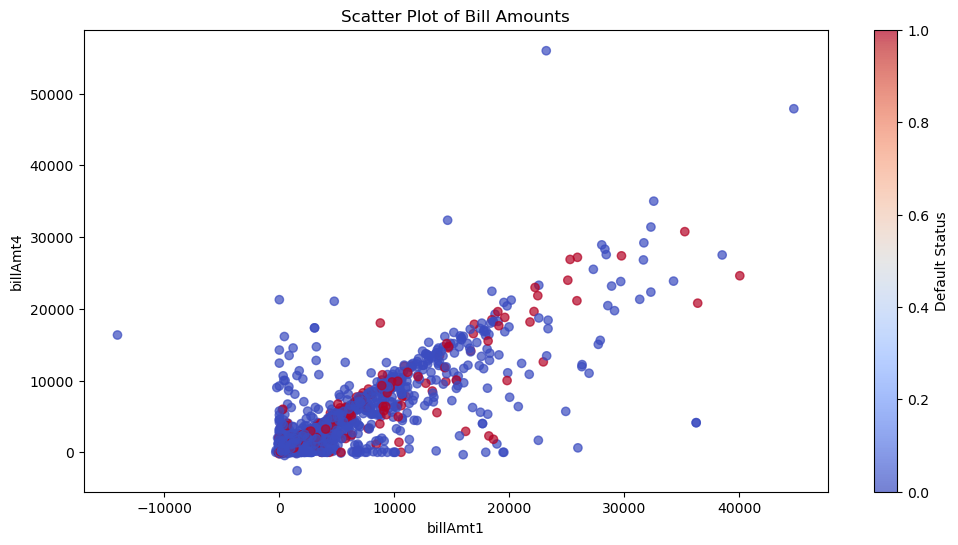

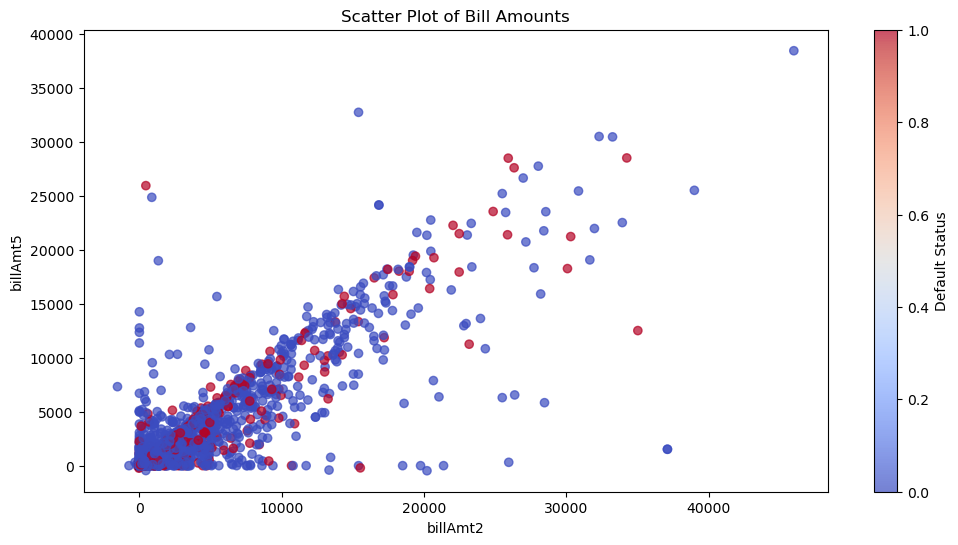

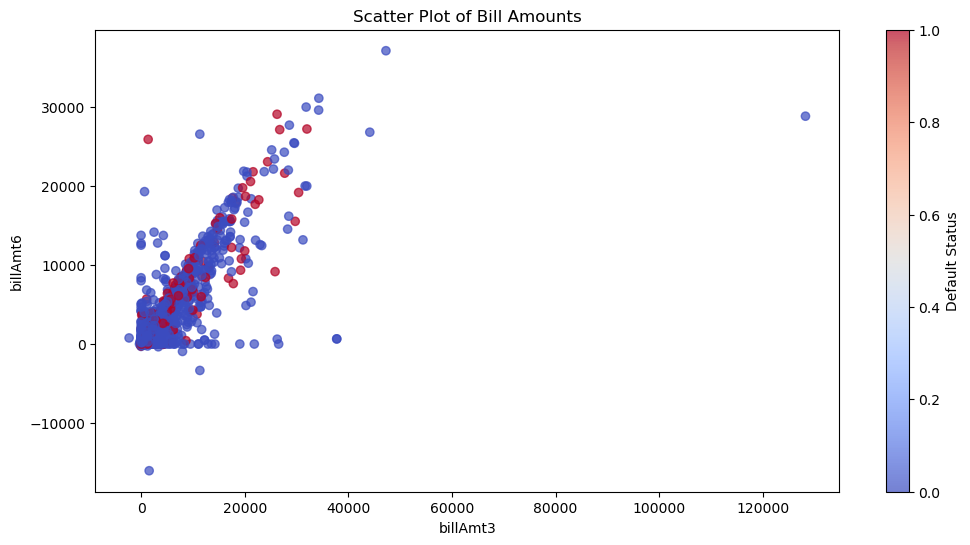

In [7]:
x_scatter = ['billAmt1', 'billAmt2', 'billAmt3']
y_scatter = ['billAmt4', 'billAmt5', 'billAmt6']

for x, y in zip(x_scatter, y_scatter):
    plt.figure(figsize=(12, 6))
    plt.scatter(X_train[x], X_train[y], c=y_train, cmap='coolwarm', alpha=0.7)
    plt.colorbar(label='Default Status')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title('Scatter Plot of Bill Amounts')
    plt.show()

In [8]:
cols = X_train.columns.tolist()

x_dropdown = widgets.Dropdown(options=cols, value=cols[0], description='X axis:')
y_dropdown = widgets.Dropdown(options=cols, value=cols[1], description='Y axis:')

def plot_scatter(x_col, y_col):
    df = X_train.copy()
    df['default'] = y_train.values

    fig = px.scatter(
        df,
        x=x_col,
        y=y_col,
        color='default',
        color_continuous_scale='RdBu_r',
        opacity=0.7,
        title=f'{x_col} vs {y_col}',
        labels={'default': 'Default Status'},
        hover_data=cols,        # shows all features on hover
    )

    fig.update_traces(marker=dict(size=5))
    fig.update_layout(
        width=900,
        height=550,
        coloraxis_colorbar=dict(
            tickvals=[0, 1],
            ticktext=['No Default', 'Default']
        )
    )
    fig.show()

widgets.interact(plot_scatter, x_col=x_dropdown, y_col=y_dropdown)

interactive(children=(Dropdown(description='X axis:', options=('creditLimit', 'gender', 'edu', 'age', 'nDelay'…

<function __main__.plot_scatter(x_col, y_col)>

In [9]:
var_dropdown = widgets.Dropdown(options=cols, value=cols[0], description='Variable:')

def plot_histogram(col):
    df = X_train.copy()
    df['default'] = y_train.values.astype(str)  # string so plotly treats it as discrete

    fig = px.histogram(
        df,
        x=col,
        color='default',
        barmode='overlay',
        opacity=0.7,
        nbins=40,
        title=f'Distribution of {col} by Default Status',
        labels={'default': 'Default Status', col: col},
        color_discrete_map={'0': '#2E86AB', '1': '#E84855'},
        category_orders={'default': ['0', '1']},
    )

    fig.update_layout(
        width=900,
        height=500,
        legend=dict(
            title='Default Status',
            itemsizing='constant',
        ),
        bargap=0.05,
    )

    fig.show()

widgets.interact(plot_histogram, col=var_dropdown)

interactive(children=(Dropdown(description='Variable:', options=('creditLimit', 'gender', 'edu', 'age', 'nDela…

<function __main__.plot_histogram(col)>

## <font color='cornflowerblue'> Logistic Regression

              precision    recall  f1-score   support

           0       0.78      0.98      0.87       768
           1       0.51      0.08      0.14       232

    accuracy                           0.77      1000
   macro avg       0.65      0.53      0.50      1000
weighted avg       0.72      0.77      0.70      1000



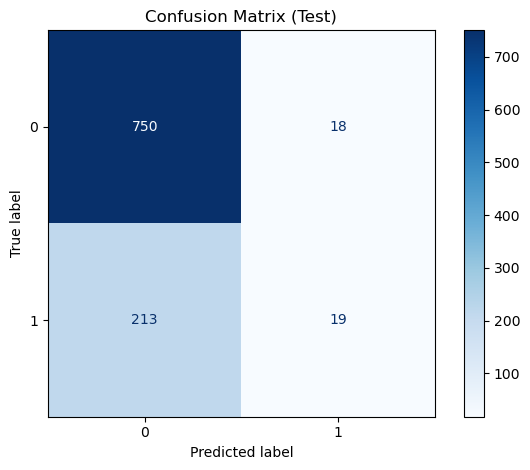

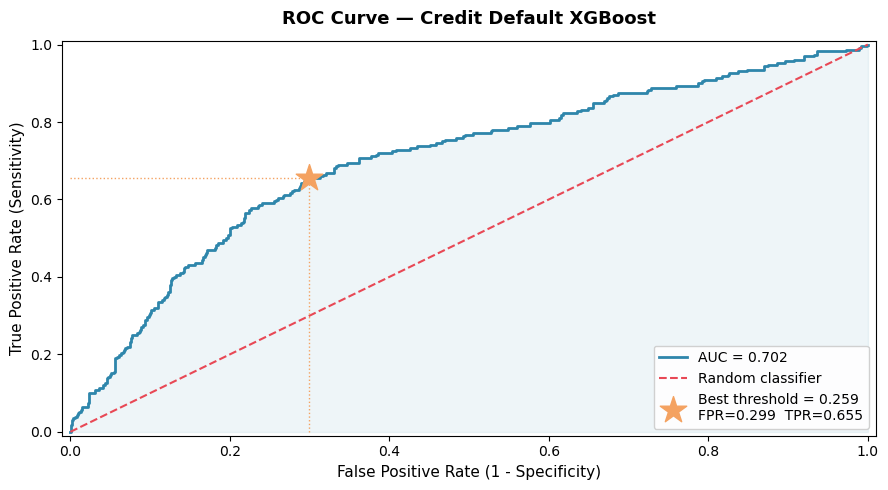

In [10]:
# Logistic Regression
model_log = LogisticRegression()
model_log.fit(X_train, y_train)

# Predictions and probabilities
y_pred_log = model_log.predict(X_test)
y_proba_log = model_log.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

curva_roc(y_proba_log, y_test)

## <font color='cornflowerblue'> XGBoost

              precision    recall  f1-score   support

           0       0.80      0.95      0.86       768
           1       0.52      0.20      0.29       232

    accuracy                           0.77      1000
   macro avg       0.66      0.57      0.58      1000
weighted avg       0.73      0.77      0.73      1000



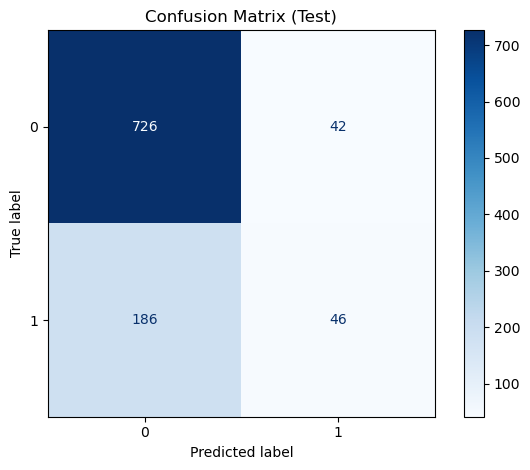

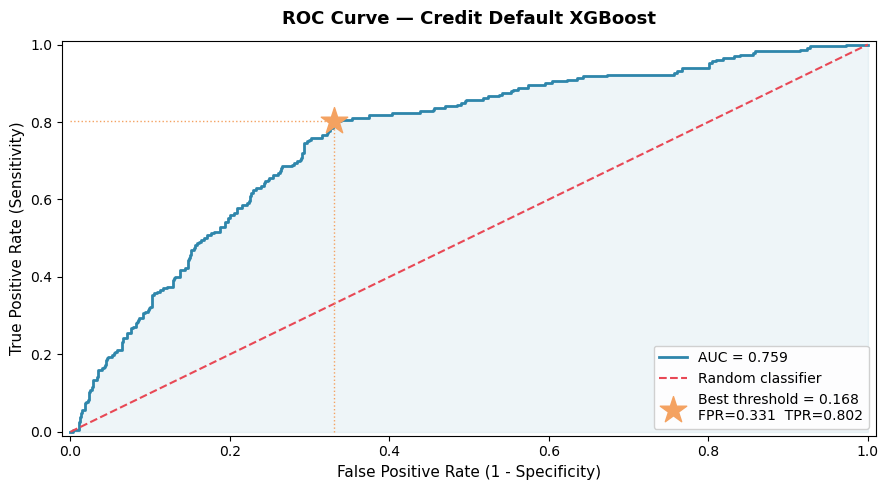

In [11]:
# XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

# Predictions and probabilities
y_pred_log = model.predict(X_test)
y_proba_log = model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_log))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_log,
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

curva_roc(y_proba_log, y_test)